In [80]:
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import BaseMessage,HumanMessage

from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph,START,END
from langgraph.checkpoint.memory import MemorySaver


from typing import List,TypedDict, Annotated
from dotenv import load_dotenv

load_dotenv()

True

In [81]:
class ChatbotState(TypedDict):
    user_messages:Annotated[List[BaseMessage], add_messages]

In [82]:
chat_model=ChatGroq(model='llama-3.1-8b-instant')

In [83]:
def chat_message(state: ChatbotState):
    response = chat_model.invoke(state['user_messages'])
    return {'user_messages': [response]}

In [84]:
checkpointer=MemorySaver()
graph = StateGraph(state_schema=ChatbotState)

graph.add_node('chat_message', chat_message)

graph.add_edge(START, 'chat_message')
graph.add_edge('chat_message', END)

workflow = graph.compile(checkpointer=checkpointer)

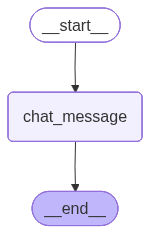

In [85]:
workflow

In [86]:
config={'configurable':{'thread_id':1}}

while True:
    user_query=input()
    
    if user_query=='exit':
        break
    
    response=workflow.invoke(input={
        'user_messages':[HumanMessage(content=user_query)]
    },config=config)
    print(f'User: {user_query}')
    print(f'AI: {response['user_messages'][-1].content}')

User: my name is sambhav
AI: Nice to meet you, Sambhav! How can I assist you today? Would you like to chat about something specific or just have a casual conversation?
User: what is my name
AI: Your name is Sambhav.
User: do you have context of my messages
AI: Yes, I have context of your messages. From what I've gathered so far, you've made the following statements:

1. Introduced yourself as Sambhav.
2. Asked me to remind you of your name.


In [87]:
workflow.get_state(config=config)

StateSnapshot(values={'user_messages': [HumanMessage(content='my name is sambhav', additional_kwargs={}, response_metadata={}, id='08f74001-2fc4-42ee-a68c-6818c86f20ce'), AIMessage(content='Nice to meet you, Sambhav! How can I assist you today? Would you like to chat about something specific or just have a casual conversation?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 42, 'total_tokens': 75, 'completion_time': 0.045344051, 'completion_tokens_details': None, 'prompt_time': 0.003172009, 'prompt_tokens_details': None, 'queue_time': 0.051858915, 'total_time': 0.04851606}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019da17c-1de4-7d11-afc7-1fbcf8cddea7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 33, 'total_tokens': 75}), HumanMessage(content